# Dự báo và dự đoán cho DSS Blinkit

Notebook này dùng cho phần việc của thành viên 3. Nội dung gồm hai bài toán:

1. **Dự báo** doanh thu và số đơn hàng theo ngày để hỗ trợ chuẩn bị tồn kho và nguồn lực vận hành.
2. **Dự đoán** rủi ro giao trễ của từng đơn hàng để hỗ trợ ưu tiên xử lý đơn hàng.

Kết quả cuối cùng cần có:

- `daily_forecast_model_comparison.csv`
- `delivery_model_comparison.csv`
- `delivery_risk_recommendations.csv`
- Các hình trong thư mục `figures`

Lưu ý quan trọng: mô hình dự đoán giao trễ chỉ được dùng các biến biết trước hoặc biết tại thời điểm xử lý đơn hàng. Không dùng các biến biết sau khi giao xong như `actual_delivery_time`, `delivery_time_minutes`, `reasons_if_delayed`, `rating`, `feedback_text`, `sentiment`.

## 0. Cách chạy notebook

Trước khi chạy, đặt cấu trúc thư mục như sau:

```text
DSS_Blinkit_Project/
    member3_forecast_prediction_ready.ipynb
    blinkit_orders_clean.csv
    blinkit_marketing_performance_clean.csv
    blinkit_data2/
        blinkit_order_items.csv
        blinkit_products.csv
        blinkit_customers.csv
        blinkit_delivery_performance.csv
```

Nếu bạn đặt dữ liệu trong thư mục `data/` thì code bên dưới cũng có thể tự tìm ở một số đường dẫn phổ biến. Chạy lần lượt từng cell từ trên xuống dưới.

## 1. Import thư viện và thiết lập đường dẫn

Cell này nạp các thư viện cần dùng. Nếu lỗi thiếu thư viện, chạy lệnh sau trong Terminal:

```bash
pip install pandas numpy matplotlib scikit-learn openpyxl
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error
)

plt.rcParams["figure.figsize"] = (12, 5)

PROJECT_DIR = Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = PROJECT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

print("Project dir:", PROJECT_DIR)
print("Output dir:", OUTPUT_DIR)
print("Figure dir:", FIGURE_DIR)


Project dir: c:\Users\UYEN\DSS_Blinkit_Project
Output dir: c:\Users\UYEN\DSS_Blinkit_Project\outputs
Figure dir: c:\Users\UYEN\DSS_Blinkit_Project\figures


## 2. Hàm tìm file dữ liệu

Hàm này giúp notebook tìm dữ liệu dù bạn để file ở thư mục hiện tại hoặc trong thư mục `data`.

In [2]:
def find_file(filename, subfolder=None):
    candidates = []
    if subfolder is not None:
        candidates += [
            PROJECT_DIR / subfolder / filename,
            PROJECT_DIR / "data" / subfolder / filename,
        ]
    candidates += [
        PROJECT_DIR / filename,
        PROJECT_DIR / "data" / filename,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Không tìm thấy {filename}. Hãy kiểm tra lại vị trí file dữ liệu."
    )

## 3. Đọc dữ liệu

Dùng `blinkit_orders_clean.csv` do thành viên 1 xử lý. Các bảng còn lại lấy từ thư mục `blinkit_data2`.

In [3]:
orders_path = find_file("blinkit_orders_clean.csv")
order_items_path = find_file("blinkit_order_items.csv", "blinkit_data2")
products_path = find_file("blinkit_products.csv", "blinkit_data2")
customers_path = find_file("blinkit_customers.csv", "blinkit_data2")
delivery_path = find_file("blinkit_delivery_performance.csv", "blinkit_data2")

orders = pd.read_csv(orders_path)
order_items = pd.read_csv(order_items_path)
products = pd.read_csv(products_path)
customers = pd.read_csv(customers_path)
delivery = pd.read_csv(delivery_path)

print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)
print("customers:", customers.shape)
print("delivery:", delivery.shape)

orders: (5000, 11)
order_items: (5000, 4)
products: (268, 10)
customers: (2500, 11)
delivery: (5000, 8)


## 4. Kiểm tra nhanh dữ liệu đầu vào

Mục đích là kiểm tra file clean đã có các cột cần thiết chưa. Nếu thiếu cột, báo lại cho thành viên 1.

In [4]:
print("orders columns:")
print(orders.columns.tolist())

print("delivery columns:")
print(delivery.columns.tolist())

print("customers columns:")
print(customers.columns.tolist())

print("products columns:")
print(products.columns.tolist())

orders columns:
['order_id', 'customer_id', 'order_date', 'promised_delivery_time', 'actual_delivery_time', 'delivery_status', 'order_total', 'payment_method', 'delivery_partner_id', 'store_id', 'order_total_clean']
delivery columns:
['order_id', 'delivery_partner_id', 'promised_time', 'actual_time', 'delivery_time_minutes', 'distance_km', 'delivery_status', 'reasons_if_delayed']
customers columns:
['customer_id', 'customer_name', 'email', 'phone', 'address', 'area', 'pincode', 'registration_date', 'customer_segment', 'total_orders', 'avg_order_value']
products columns:
['product_id', 'product_name', 'category', 'brand', 'price', 'mrp', 'margin_percentage', 'shelf_life_days', 'min_stock_level', 'max_stock_level']


## 5. Tạo bảng dữ liệu tổng hợp cho phần mô hình

Bảng tổng hợp ở mức đơn hàng được tạo bằng cách nối đơn hàng, chi tiết đơn hàng, sản phẩm, khách hàng và thông tin giao hàng.

Trong file `orders_clean`, cột `order_total` gốc có thể vẫn còn. Để tránh nhầm, code đổi tên nó thành `order_total_raw` và dùng `order_total_clean` cho phân tích doanh thu.

In [5]:
orders_model = orders.copy()
if "order_total" in orders_model.columns and "order_total_clean" in orders_model.columns:
    orders_model = orders_model.rename(columns={"order_total": "order_total_raw"})

customers_model = customers.copy()
customers_model = customers_model.rename(columns={
    "total_orders": "lifetime_total_orders",
    "avg_order_value": "lifetime_avg_order_value"
})

delivery_extra = delivery[[
    "order_id", "distance_km", "delivery_time_minutes", "reasons_if_delayed"
]].copy()
delivery_extra = delivery_extra.rename(columns={
    "delivery_time_minutes": "lateness_minutes"
})

df = orders_model.merge(order_items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(customers_model, on="customer_id", how="left")
df = df.merge(delivery_extra, on="order_id", how="left")

print("Master data shape:", df.shape)
df.head()

Master data shape: (5000, 36)


,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total_raw,payment_method,delivery_partner_id,store_id,...,address,area,pincode,registration_date,customer_segment,lifetime_total_orders,lifetime_avg_order_value,distance_km,lateness_minutes,reasons_if_delayed
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,...,"H.No. 330\nRana Path, Sagar 712033",Allahabad,911359,2024-09-02,Regular,13,749.95,0.96,-5.0,NaN
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,...,"49, Sarkar Zila, Navi Mumbai-077374",Thrissur,856100,2023-11-07,New,5,958.06,0.98,2.0,Traffic
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,...,"14/351, Agarwal Path\nMedininagar 636193",Vellore,117423,2024-01-05,Inactive,4,327.93,3.83,4.0,Traffic
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,...,"20/47\nRatta Chowk, Sonipat-022522",Gaya,288459,2023-12-25,Premium,5,273.38,2.76,-1.0,NaN
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,...,"H.No. 68, Gaba Road\nKhandwa 040880",Asansol,149383,2024-10-02,Premium,14,763.10,2.63,1.0,Traffic


## 6. Xử lý thời gian và tạo biến mới

Cell này tạo các biến thời gian dùng cho cả dự báo và dự đoán:

- `order_day`: ngày đặt hàng.
- `order_hour`: giờ đặt hàng.
- `day_of_week`: thứ trong tuần.
- `month`: tháng.
- `is_weekend`: có phải cuối tuần không.
- `promised_minutes`: số phút từ lúc đặt đến giờ hứa giao.

In [6]:
for col in ["order_date", "promised_delivery_time", "actual_delivery_time"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df["order_day"] = df["order_date"].dt.floor("D")
df["order_hour"] = df["order_date"].dt.hour
df["day_of_week"] = df["order_date"].dt.dayofweek
df["month"] = df["order_date"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

df["promised_minutes"] = (
    df["promised_delivery_time"] - df["order_date"]
).dt.total_seconds() / 60

def part_of_day(hour):
    if pd.isna(hour):
        return "Unknown"
    if 5 <= hour < 11:
        return "Morning"
    if 11 <= hour < 14:
        return "Noon"
    if 14 <= hour < 18:
        return "Afternoon"
    if 18 <= hour < 22:
        return "Evening"
    return "Night"

df["part_of_day"] = df["order_hour"].apply(part_of_day)

print(df[["order_date", "order_day", "order_hour", "day_of_week", "month", "is_weekend", "promised_minutes", "part_of_day"]].head())

           order_date  order_day  order_hour  day_of_week  month  is_weekend  \
0 2024-07-17 08:34:01 2024-07-17           8            2      7           0   
1 2024-05-28 13:14:29 2024-05-28          13            1      5           0   
2 2024-09-23 13:07:12 2024-09-23          13            0      9           0   
3 2023-11-24 16:16:56 2023-11-24          16            4     11           0   
4 2023-11-20 05:00:39 2023-11-20           5            0     11           0   

   promised_minutes part_of_day  
0              18.0     Morning  
1              11.0        Noon  
2              18.0        Noon  
3              18.0   Afternoon  
4              17.0     Morning  


## 7. Lưu bảng tổng hợp

Bảng này có thể đưa cho thành viên làm Streamlit hoặc agent sau này.

In [7]:
master_path = OUTPUT_DIR / "master_order_data_for_member3.csv"
df.to_csv(master_path, index=False)
print("Đã lưu:", master_path)

Đã lưu: c:\Users\UYEN\DSS_Blinkit_Project\outputs\master_order_data_for_member3.csv


# PHẦN A. DỰ BÁO DOANH THU VÀ SỐ ĐƠN HÀNG

Dự báo trả lời câu hỏi: trong tương lai gần, doanh thu và số đơn hàng có xu hướng như thế nào?

Kết quả dự báo hỗ trợ quyết định cấp kế hoạch, ví dụ chuẩn bị tồn kho, nhân sự giao hàng và nguồn lực vận hành.

## A1. Tạo dữ liệu theo ngày

Dữ liệu dự báo phải ở dạng chuỗi thời gian. Vì vậy ta tổng hợp dữ liệu từ mức đơn hàng sang mức ngày.

In [8]:
daily = (
    df.groupby("order_day")
    .agg(
        daily_revenue=("order_total_clean", "sum"),
        daily_orders=("order_id", "nunique")
    )
    .reset_index()
    .sort_values("order_day")
)

full_dates = pd.date_range(daily["order_day"].min(), daily["order_day"].max(), freq="D")
daily = (
    daily.set_index("order_day")
    .reindex(full_dates)
    .rename_axis("order_day")
    .reset_index()
)

daily["daily_revenue"] = daily["daily_revenue"].fillna(0)
daily["daily_orders"] = daily["daily_orders"].fillna(0)

print(daily.shape)
daily.head()

(600, 3)


,order_day,daily_revenue,daily_orders
0,2023-03-16,7257.89,9
1,2023-03-17,4193.24,6
2,2023-03-18,9591.13,7
3,2023-03-19,8379.42,7
4,2023-03-20,2531.09,4


## A2. Vẽ xu hướng doanh thu và số đơn hàng

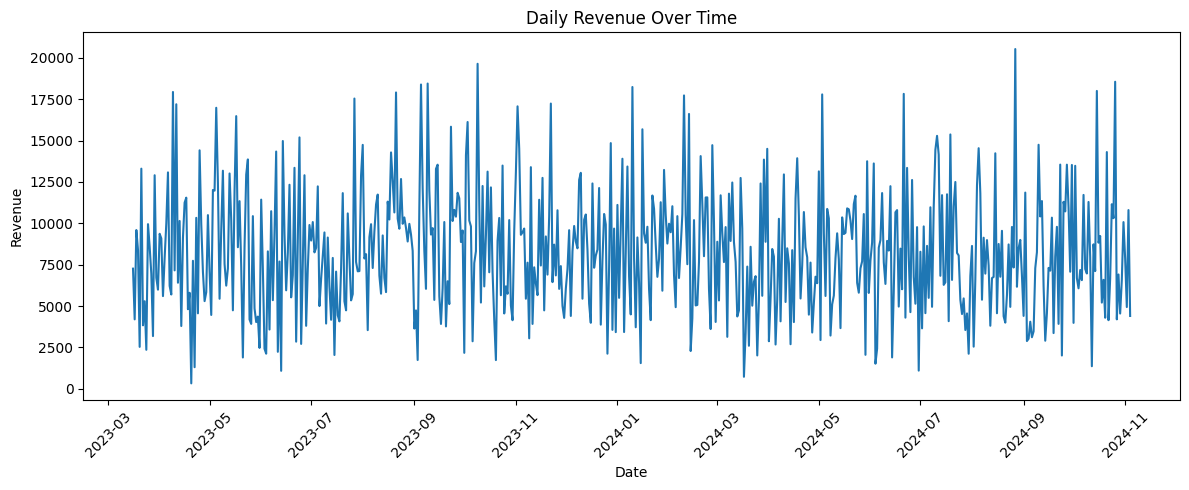

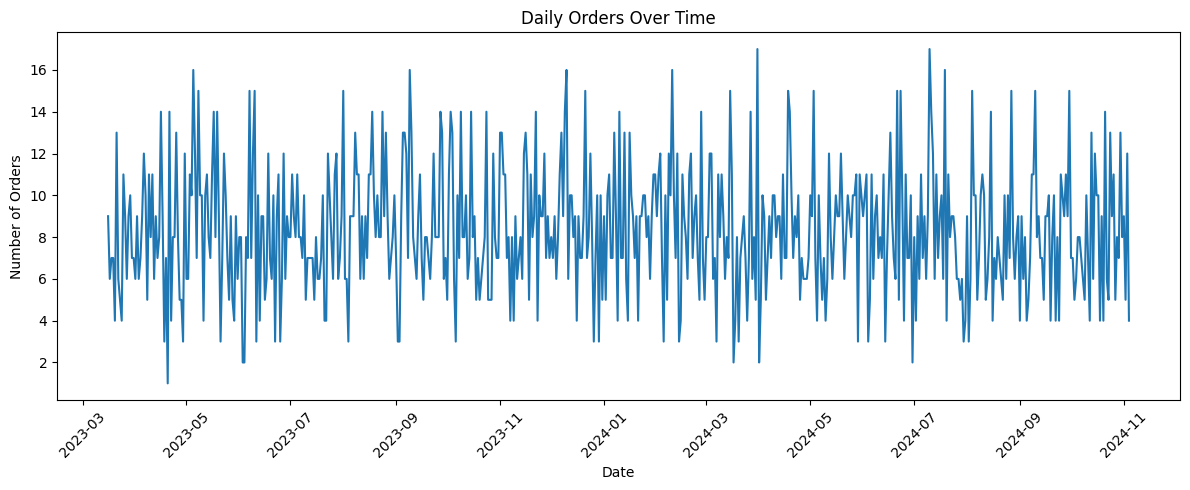

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(daily["order_day"], daily["daily_revenue"])
plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "daily_revenue_trend.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(daily["order_day"], daily["daily_orders"])
plt.title("Daily Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "daily_orders_trend.png", dpi=150)
plt.show()

## A3. Tạo biến cho mô hình dự báo

Các biến được tạo gồm biến thời gian, biến trễ và trung bình trượt. Biến trễ giúp mô hình học từ giá trị của các ngày trước.

In [10]:
def create_forecast_features(data, target_col):
    data = data.copy()
    data["day_index"] = np.arange(len(data))
    data["day_of_week"] = data["order_day"].dt.dayofweek
    data["month"] = data["order_day"].dt.month
    data["is_weekend"] = data["day_of_week"].isin([5, 6]).astype(int)
    
    for lag in [1, 7, 14]:
        data[f"{target_col}_lag_{lag}"] = data[target_col].shift(lag)
    
    data[f"{target_col}_rolling_7"] = data[target_col].shift(1).rolling(7).mean()
    data[f"{target_col}_rolling_14"] = data[target_col].shift(1).rolling(14).mean()
    
    return data.dropna().reset_index(drop=True)

## A4. Hàm huấn luyện và đánh giá mô hình dự báo

Các mô hình dùng thử:

- Trung bình động 7 ngày: mô hình nền đơn giản.
- Linear Regression: mô hình tuyến tính dễ giải thích.
- Random Forest Regressor: mô hình phi tuyến, dùng để so sánh.

Chỉ số đánh giá:

- MAE: sai số tuyệt đối trung bình.
- RMSE: căn bậc hai của sai số bình phương trung bình.

In [11]:
def evaluate_forecast_models(daily_data, target_col):
    data = create_forecast_features(daily_data, target_col)
    
    feature_cols = [
        "day_index", "day_of_week", "month", "is_weekend",
        f"{target_col}_lag_1", f"{target_col}_lag_7", f"{target_col}_lag_14",
        f"{target_col}_rolling_7", f"{target_col}_rolling_14"
    ]
    
    split_index = int(len(data) * 0.8)
    train = data.iloc[:split_index]
    test = data.iloc[split_index:]
    
    X_train = train[feature_cols]
    y_train = train[target_col]
    X_test = test[feature_cols]
    y_test = test[target_col]
    
    results = []
    predictions = test[["order_day", target_col]].copy()
    
    baseline_pred = test[f"{target_col}_rolling_7"]
    results.append({
        "target": target_col,
        "model": "7-day Moving Average",
        "MAE": mean_absolute_error(y_test, baseline_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, baseline_pred))
    })
    predictions["pred_7day_moving_average"] = baseline_pred.values
    
    models = {
        "Linear Regression": LinearRegression(),
        "Random Forest Regressor": RandomForestRegressor(
            n_estimators=200,
            max_depth=8,
            random_state=42
        )
    }
    
    trained_models = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        
        results.append({
            "target": target_col,
            "model": name,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred))
        })
        predictions[f"pred_{name}"] = pred
        trained_models[name] = model
    
    return pd.DataFrame(results), predictions, trained_models, feature_cols

## A5. Chạy dự báo doanh thu

In [12]:
revenue_results, revenue_predictions, revenue_models, revenue_features = evaluate_forecast_models(
    daily, "daily_revenue"
)

revenue_results

,target,model,MAE,RMSE
0,daily_revenue,7-day Moving Average,3453.586041,4196.035048
1,daily_revenue,Linear Regression,3072.108444,3821.266267
2,daily_revenue,Random Forest Regressor,3067.492291,3880.304317


## A6. Chạy dự báo số đơn hàng

In [13]:
orders_results, orders_predictions, orders_models, orders_features = evaluate_forecast_models(
    daily, "daily_orders"
)

orders_results

,target,model,MAE,RMSE
0,daily_orders,7-day Moving Average,2.690073,3.364360
1,daily_orders,Linear Regression,2.525122,3.113832
2,daily_orders,Random Forest Regressor,2.499053,3.166202


## A7. Lưu kết quả dự báo và vẽ biểu đồ so sánh

In [14]:
forecast_results = pd.concat([revenue_results, orders_results], ignore_index=True)
forecast_results.to_csv(OUTPUT_DIR / "daily_forecast_model_comparison.csv", index=False)

revenue_predictions.to_csv(OUTPUT_DIR / "daily_revenue_predictions.csv", index=False)
orders_predictions.to_csv(OUTPUT_DIR / "daily_orders_predictions.csv", index=False)

forecast_results

,target,model,MAE,RMSE
0,daily_revenue,7-day Moving Average,3453.586041,4196.035048
1,daily_revenue,Linear Regression,3072.108444,3821.266267
2,daily_revenue,Random Forest Regressor,3067.492291,3880.304317
3,daily_orders,7-day Moving Average,2.690073,3.364360
4,daily_orders,Linear Regression,2.525122,3.113832
5,daily_orders,Random Forest Regressor,2.499053,3.166202


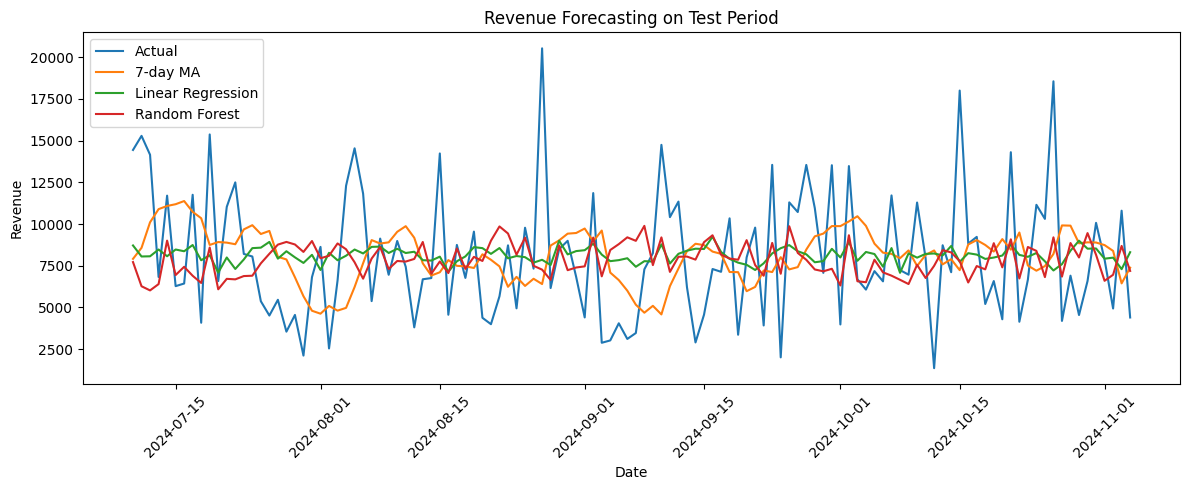

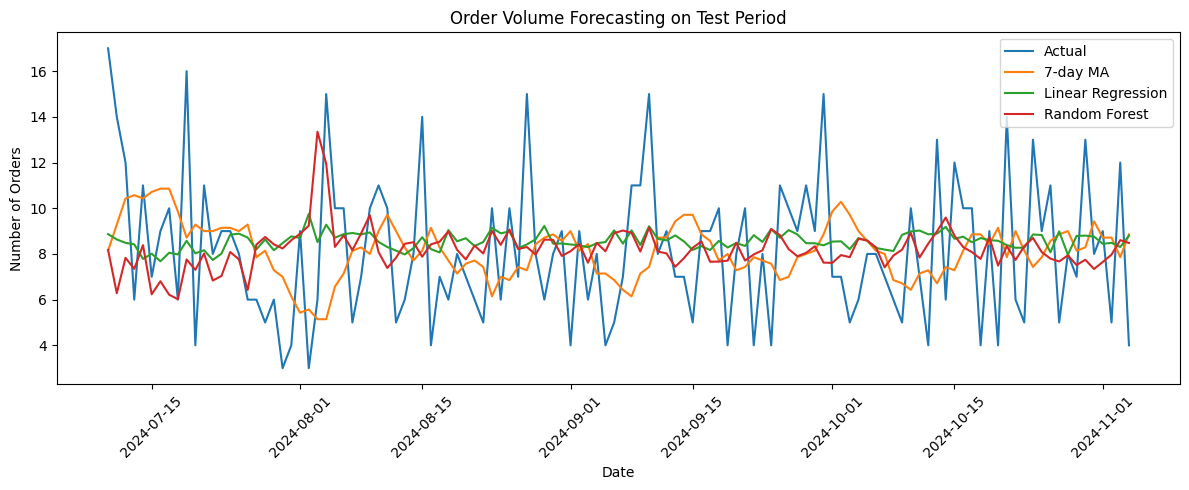

In [15]:
plt.figure(figsize=(12, 5))
plt.plot(revenue_predictions["order_day"], revenue_predictions["daily_revenue"], label="Actual")
plt.plot(revenue_predictions["order_day"], revenue_predictions["pred_7day_moving_average"], label="7-day MA")
plt.plot(revenue_predictions["order_day"], revenue_predictions["pred_Linear Regression"], label="Linear Regression")
plt.plot(revenue_predictions["order_day"], revenue_predictions["pred_Random Forest Regressor"], label="Random Forest")
plt.title("Revenue Forecasting on Test Period")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "revenue_forecast_test.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(orders_predictions["order_day"], orders_predictions["daily_orders"], label="Actual")
plt.plot(orders_predictions["order_day"], orders_predictions["pred_7day_moving_average"], label="7-day MA")
plt.plot(orders_predictions["order_day"], orders_predictions["pred_Linear Regression"], label="Linear Regression")
plt.plot(orders_predictions["order_day"], orders_predictions["pred_Random Forest Regressor"], label="Random Forest")
plt.title("Order Volume Forecasting on Test Period")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "orders_forecast_test.png", dpi=150)
plt.show()

# PHẦN B. DỰ ĐOÁN RỦI RO GIAO TRỄ

Dự đoán trả lời câu hỏi: một đơn hàng cụ thể có nguy cơ giao trễ hay không?

Kết quả dự đoán hỗ trợ quyết định cấp vận hành, giúp nhà quản lý ưu tiên xử lý các đơn hàng có rủi ro cao.

## B1. Tạo biến mục tiêu

Biến mục tiêu là `delayed`:

- `0`: giao đúng giờ.
- `1`: giao trễ nhẹ hoặc trễ đáng kể.

In [16]:
df["delayed"] = df["delivery_status"].isin([
    "Slightly Delayed", "Significantly Delayed"
]).astype(int)

print(df["delivery_status"].value_counts())
print("Tỷ lệ delayed:")
print(df["delayed"].value_counts(normalize=True))

delivery_status
On Time                  3470
Slightly Delayed         1037
Significantly Delayed     493
Name: count, dtype: int64
Tỷ lệ delayed:
delayed
0    0.694
1    0.306
Name: proportion, dtype: float64


## B2. Chọn biến đầu vào

Nguyên tắc: chỉ dùng các biến biết trước hoặc biết tại thời điểm xử lý đơn hàng.

Không dùng các biến gây rò rỉ dữ liệu như:

```text
actual_delivery_time
lateness_minutes
reasons_if_delayed
rating
feedback_text
sentiment
feedback_category
```

Không dùng `store_id` và `delivery_partner_id` làm biến đầu vào vì trong dữ liệu hiện tại hai cột này gần như là mã định danh riêng của từng đơn hàng, không tạo thành nhóm vận hành lặp lại để mô hình học quy luật có ý nghĩa. Có thể giữ hai cột này trong dữ liệu gốc để tra cứu, nhưng không đưa vào mô hình dự đoán.


In [17]:
features = [
    "order_total_clean",
    "payment_method",
    "distance_km",
    "quantity",
    "unit_price",
    "category",
    "price",
    "mrp",
    "margin_percentage",
    "shelf_life_days",
    "customer_segment",
    "lifetime_total_orders",
    "lifetime_avg_order_value",
    "order_hour",
    "day_of_week",
    "month",
    "is_weekend",
    "part_of_day",
    "promised_minutes"
]

target = "delayed"

missing_features = [col for col in features if col not in df.columns]
if missing_features:
    raise ValueError(f"Thiếu các cột: {missing_features}")

model_df = df[features + [target]].copy()
print(model_df.shape)
model_df.head()


(5000, 20)


,order_total_clean,payment_method,distance_km,quantity,unit_price,category,price,mrp,margin_percentage,shelf_life_days,customer_segment,lifetime_total_orders,lifetime_avg_order_value,order_hour,day_of_week,month,is_weekend,part_of_day,promised_minutes,delayed
0,1551.09,Cash,0.96,3,517.03,Pet Care,517.03,795.43,35.0,365,Regular,13,749.95,8,2,7,0,Morning,18.0,0
1,881.42,Cash,0.98,1,881.42,Cold Drinks & Juices,881.42,1259.17,30.0,180,New,5,958.06,13,1,5,0,Noon,11.0,0
2,1847.68,UPI,3.83,2,923.84,Dairy & Breakfast,923.84,1154.80,20.0,7,Inactive,4,327.93,13,0,9,0,Noon,18.0,0
3,874.78,Card,2.76,1,874.78,Cold Drinks & Juices,874.78,1249.69,30.0,180,Premium,5,273.38,16,4,11,0,Afternoon,18.0,0
4,1953.10,Cash,2.63,2,976.55,Snacks & Munchies,976.55,1502.38,35.0,90,Premium,14,763.10,5,0,11,0,Morning,17.0,0


## B3. Xử lý dữ liệu thiếu cho mô hình

Biến chữ được điền bằng `Unknown`. Biến số được điền bằng median.

In [18]:
for col in model_df.select_dtypes(include=["object"]).columns:
    model_df[col] = model_df[col].fillna("Unknown")

for col in model_df.select_dtypes(include=["number"]).columns:
    model_df[col] = model_df[col].fillna(model_df[col].median())

print(model_df.isna().sum().sum())

0


## B4. Chia train và test

Dùng stratify để giữ tỷ lệ đơn trễ và đúng giờ tương đối giống nhau giữa train và test.

In [19]:
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train delayed ratio:", y_train.mean())
print("Test delayed ratio:", y_test.mean())

Train: (4000, 19)
Test: (1000, 19)
Train delayed ratio: 0.306
Test delayed ratio: 0.306


## B5. Tạo pipeline tiền xử lý

Biến số được chuẩn hóa bằng `StandardScaler`. Biến phân loại được mã hóa bằng `OneHotEncoder`.

In [20]:
numeric_features = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Numeric features: ['order_total_clean', 'distance_km', 'quantity', 'unit_price', 'price', 'mrp', 'margin_percentage', 'shelf_life_days', 'lifetime_total_orders', 'lifetime_avg_order_value', 'order_hour', 'day_of_week', 'month', 'is_weekend', 'promised_minutes']
Categorical features: ['payment_method', 'category', 'customer_segment', 'part_of_day']


## B6. Huấn luyện và so sánh các mô hình phân lớp

Notebook thử nghiệm các mô hình trong nhóm kiến thức phân lớp và ensemble learning: Logistic Regression, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, AdaBoost và SVM.

Không chọn mô hình chỉ theo accuracy. Với bài toán cảnh báo giao trễ, mô hình cần phát hiện được nhiều đơn trễ, nên ưu tiên F1 và Recall của lớp `delayed = 1`.


In [21]:
classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=30,
        class_weight="balanced",
        random_state=42
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=30,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        class_weight="balanced",
        probability=True,
        random_state=42
    )
}

classification_results = []
trained_classifiers = {}
classification_reports = {}

for name, model in classification_models.items():
    clf = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    classification_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0)
    })

    trained_classifiers[name] = clf
    classification_reports[name] = classification_report(y_test, y_pred, zero_division=0)

    print("\n====================")
    print(name)
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))

classification_results_df = pd.DataFrame(classification_results)
classification_results_df = classification_results_df.sort_values(
    by=["f1", "recall", "precision", "accuracy"],
    ascending=False
).reset_index(drop=True)

classification_results_df



Logistic Regression
Confusion matrix:
[[345 349]
 [135 171]]
              precision    recall  f1-score   support

           0       0.72      0.50      0.59       694
           1       0.33      0.56      0.41       306

    accuracy                           0.52      1000
   macro avg       0.52      0.53      0.50      1000
weighted avg       0.60      0.52      0.53      1000


Decision Tree
Confusion matrix:
[[391 303]
 [157 149]]
              precision    recall  f1-score   support

           0       0.71      0.56      0.63       694
           1       0.33      0.49      0.39       306

    accuracy                           0.54      1000
   macro avg       0.52      0.53      0.51      1000
weighted avg       0.60      0.54      0.56      1000


Random Forest
Confusion matrix:
[[434 260]
 [181 125]]
              precision    recall  f1-score   support

           0       0.71      0.63      0.66       694
           1       0.32      0.41      0.36       306

    accu

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.516,0.328846,0.558824,0.414044
1,SVM,0.531,0.328421,0.509804,0.399488
2,Decision Tree,0.540,0.329646,0.486928,0.393140
3,Extra Trees,0.550,0.332558,0.467320,0.388587
4,Random Forest,0.559,0.324675,0.408497,0.361795
5,Gradient Boosting,0.687,0.333333,0.022876,0.042813
6,AdaBoost,0.694,0.000000,0.000000,0.000000


## B7. Lưu kết quả so sánh mô hình

In [22]:
classification_results_df.to_csv(OUTPUT_DIR / "delivery_model_comparison.csv", index=False)
classification_results_df

,model,accuracy,precision,recall,f1
0,Logistic Regression,0.516,0.328846,0.558824,0.414044
1,SVM,0.531,0.328421,0.509804,0.399488
2,Decision Tree,0.540,0.329646,0.486928,0.393140
3,Extra Trees,0.550,0.332558,0.467320,0.388587
4,Random Forest,0.559,0.324675,0.408497,0.361795
5,Gradient Boosting,0.687,0.333333,0.022876,0.042813
6,AdaBoost,0.694,0.000000,0.000000,0.000000


## B8. Chọn mô hình chính

Tạm thời chọn `Decision Tree` vì dễ giải thích và phù hợp với DSS. Nếu sau khi chạy kết quả quá kém, bạn có thể đổi sang mô hình khác.

Trong báo cáo cần giải thích: với bài giao trễ, không chỉ nhìn accuracy. Recall của lớp giao trễ rất quan trọng vì hệ thống cần phát hiện càng nhiều đơn có nguy cơ trễ càng tốt.

In [23]:
# Automatically select the main prediction model.
# We select by F1 first, then Recall, Precision and Accuracy.
# This is better than selecting by Accuracy only because a high-accuracy model
# may still miss most delayed orders.

selection_metrics = ["f1", "recall", "precision", "accuracy"]

best_row = (
    classification_results_df
    .sort_values(by=selection_metrics, ascending=False)
    .iloc[0]
)

best_model_name = best_row["model"]
best_classifier = trained_classifiers[best_model_name]

# Keep Decision Tree as a separate explanation model.
# It is useful because it can be converted into human-readable decision rules.

explain_model_name = "Decision Tree"
explain_classifier = trained_classifiers[explain_model_name]

print("Selected model for risk scoring:", best_model_name)
print(best_row)
print("Explanation model:", explain_model_name)


Selected model for risk scoring: Logistic Regression
model        Logistic Regression
accuracy                   0.516
precision               0.328846
recall                  0.558824
f1                      0.414044
Name: 0, dtype: object
Explanation model: Decision Tree


## B9. Tạo điểm rủi ro và mức rủi ro cho từng đơn hàng

Mô hình chính được chọn tự động theo F1/Recall sẽ tạo `delay_risk_score`, tức xác suất mô hình dự đoán đơn hàng bị trễ. Sau đó chia xác suất thành ba mức: Low, Medium, High.

Decision Tree vẫn được dùng riêng ở phần sau để trích luật giải thích, không bắt buộc phải là mô hình có F1 cao nhất.


In [24]:
risk_score = best_classifier.predict_proba(X)[:, 1]
df["delay_risk_score"] = risk_score

# Use relative risk levels instead of fixed thresholds.
# Reason: in this dataset, predicted probabilities are concentrated in a narrow range.
# A fixed threshold such as 0.7 may produce no High-risk orders.
# Therefore, High means top 10% highest predicted risk, Medium means the next 40%,
# and Low means the remaining 50%.

high_threshold = df["delay_risk_score"].quantile(0.90)
medium_threshold = df["delay_risk_score"].quantile(0.50)

def risk_level(score):
    if score >= high_threshold:
        return "High"
    if score >= medium_threshold:
        return "Medium"
    return "Low"

df["delay_risk_level"] = df["delay_risk_score"].apply(risk_level)

print("Selected model for risk scoring:", best_model_name)
print("High threshold:", high_threshold)
print("Medium threshold:", medium_threshold)

risk_summary = (
    df.groupby("delay_risk_level")
    .agg(
        number_of_orders=("order_id", "count"),
        actual_delay_rate=("delayed", "mean"),
        avg_risk_score=("delay_risk_score", "mean")
    )
    .reset_index()
    .sort_values("avg_risk_score", ascending=False)
)

risk_summary


Selected model for risk scoring: Logistic Regression
High threshold: 0.5566610395243271
Medium threshold: 0.49959806602005574


,delay_risk_level,number_of_orders,actual_delay_rate,avg_risk_score
0,High,500,0.3780,0.578579
2,Medium,2000,0.3250,0.523785
1,Low,2500,0.2764,0.463045


## B10. Tạo khuyến nghị quyết định

Đây là phần biến mô hình thành hệ hỗ trợ quyết định. Hệ thống không chỉ nói rủi ro cao hay thấp, mà đưa ra hành động gợi ý.

In [25]:
def make_delivery_recommendation(row):
    if row["delay_risk_level"] == "High":
        if row["distance_km"] >= 3:
            return "Ưu tiên xử lý vì đơn có rủi ro trễ cao và khoảng cách giao hàng xa."
        if row["promised_minutes"] <= 15:
            return "Ưu tiên xử lý vì đơn có rủi ro trễ cao và thời gian hứa giao ngắn."
        return "Theo dõi sát vì mô hình dự đoán đơn có rủi ro giao trễ cao."
    
    if row["delay_risk_level"] == "Medium":
        return "Cần theo dõi, chưa cần ưu tiên cao nhưng không nên bỏ qua."
    
    return "Rủi ro thấp, xử lý theo quy trình bình thường."

df["delivery_recommendation"] = df.apply(make_delivery_recommendation, axis=1)

risk_output_cols = [
    "order_id", "customer_id", "order_date", "order_total_clean", "payment_method",
    "distance_km", "category", "customer_segment", "promised_minutes",
    "delivery_status", "delayed", "delay_risk_score", "delay_risk_level",
    "delivery_recommendation"
]

risk_output = df[risk_output_cols].copy().sort_values("delay_risk_score", ascending=False)
risk_output.to_csv(OUTPUT_DIR / "delivery_risk_recommendations.csv", index=False)
risk_output.head(20)

,order_id,customer_id,order_date,order_total_clean,payment_method,distance_km,category,customer_segment,promised_minutes,delivery_status,delayed,delay_risk_score,delay_risk_level,delivery_recommendation
910,15642223,85020453,2023-11-06 21:10:23,291.12,Cash,1.44,Grocery & Staples,Premium,14.0,On Time,0,0.640089,High,Ưu tiên xử lý vì đơn có rủi ro trễ cao và thời...
4915,2548452255,44776601,2023-09-18 02:09:26,113.40,Wallet,1.70,Grocery & Staples,Regular,15.0,Significantly Delayed,1,0.639954,High,Ưu tiên xử lý vì đơn có rủi ro trễ cao và thời...
2716,8045361592,16543242,2024-10-11 11:49:32,976.55,Wallet,4.06,Snacks & Munchies,Premium,15.0,On Time,0,0.638622,High,Ưu tiên xử lý vì đơn có rủi ro trễ cao và khoả...
687,6767935470,70372270,2024-04-17 01:23:52,951.27,Cash,4.68,Snacks & Munchies,New,19.0,On Time,0,0.633065,High,Ưu tiên xử lý vì đơn có rủi ro trễ cao và khoả...
4357,6256637306,3096845,2023-11-07 11:20:32,783.09,Cash,2.47,Pharmacy,New,17.0,Slightly Delayed,1,0.631240,High,Theo dõi sát vì mô hình dự đoán đơn có rủi ro ...
694,2002067527,45166203,2023-11-06 23:08:27,594.45,Wallet,3.85,Grocery & Staples,Regular,10.0,On Time,0,0.627808,High,Ưu tiên xử lý vì đơn có rủi ro trễ cao và khoả...
2783,896919031,42366724,2024-10-08 03:01:32,499.26,Wallet,3.17,Snacks & Munchies,Inactive,11.0,On Time,0,0.627608,High,Ưu tiên xử lý vì đơn có rủi ro trễ cao và khoả...
492,6573705785,24000329,2023-11-23 12:34:22,836.96,Wallet,4.68,Snacks & Munchies,Premium,15.0,On Time,0,0.627109,High,Ưu tiên xử lý vì đơn có rủi ro trễ cao và khoả...
3914,6409437174,3399251,2023-12-06 13:00:16,66.42,Wallet,4.46,Household Care,New,14.0,Significantly Delayed,1,0.626976,High,Ưu tiên xử lý vì đơn có rủi ro trễ cao và khoả...
1127,5008395294,1108176,2023-12-22 09:09:45,113.40,Cash,2.33,Grocery & Staples,Premium,13.0,Significantly Delayed,1,0.626641,High,Ưu tiên xử lý vì đơn có rủi ro trễ cao và thời...


## B11. Rút luật từ Decision Tree

Cell này in cây quyết định ở dạng text. Bạn đọc kết quả, chọn 3 đến 5 luật dễ hiểu rồi viết lại bằng ngôn ngữ kinh doanh trong báo cáo.

In [26]:
# Train a separate Decision Tree explanation model using unscaled numeric features.
# This makes the exported rules easier to understand because thresholds are shown
# in original units instead of standardized values.

explain_preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

explain_tree = Pipeline(steps=[
    ("preprocess", explain_preprocess),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42
    ))
])

explain_tree.fit(X_train, y_train)

tree_model = explain_tree.named_steps["model"]
preprocessor = explain_tree.named_steps["preprocess"]
feature_names = preprocessor.get_feature_names_out()

rules = export_text(
    tree_model,
    feature_names=list(feature_names),
    max_depth=4
)

print(rules)

with open(OUTPUT_DIR / "decision_tree_rules.txt", "w", encoding="utf-8") as f:
    f.write(rules)


|--- num__lifetime_avg_order_value <= 225.78
|   |--- class: 0
|--- num__lifetime_avg_order_value >  225.78
|   |--- num__order_total_clean <= 251.07
|   |   |--- cat__customer_segment_Inactive <= 0.50
|   |   |   |--- num__order_hour <= 16.50
|   |   |   |   |--- num__day_of_week <= 2.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- num__day_of_week >  2.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- num__order_hour >  16.50
|   |   |   |   |--- num__order_total_clean <= 154.36
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- num__order_total_clean >  154.36
|   |   |   |   |   |--- class: 0
|   |   |--- cat__customer_segment_Inactive >  0.50
|   |   |   |--- num__mrp <= 161.03
|   |   |   |   |--- class: 0
|   |   |   |--- num__mrp >  161.03
|   |   |   |   |--- class: 0
|   |--- num__order_total_clean >  251.07
|   |   |--- num__mrp <= 497.09
|   |   |   |--- num__order_total_clean <= 877.12
|   |   |   |   |--- num__month <= 4.50
|   |   |   |   |   |--- class

## B12. Viết nhận xét sau khi chạy

Sau khi chạy xong, điền vào báo cáo theo hướng sau:

```text
Mô hình dự báo doanh thu tốt nhất theo MAE là: [ĐIỀN]. MAE = [ĐIỀN], RMSE = [ĐIỀN].
Mô hình dự báo số đơn hàng tốt nhất theo MAE là: [ĐIỀN]. MAE = [ĐIỀN], RMSE = [ĐIỀN].

Mô hình dự đoán giao trễ chính là: [ĐIỀN THEO CODE TỰ CHỌN].
Accuracy = [ĐIỀN], Precision = [ĐIỀN], Recall = [ĐIỀN], F1 = [ĐIỀN].

Lý do chọn mô hình: mô hình được chọn theo F1, sau đó xét Recall vì mục tiêu của hệ thống là phát hiện sớm đơn hàng có nguy cơ giao trễ, không chỉ tối đa hóa accuracy.

Decision Tree được dùng bổ sung để giải thích luật quyết định, vì cây quyết định có thể chuyển thành các luật dễ hiểu cho nhà quản lý.

Khuyến nghị chính cho quản lý vận hành: ưu tiên theo dõi và xử lý các đơn hàng có delay_risk_level = High, đặc biệt các đơn có khoảng cách xa hoặc thời gian hứa giao ngắn.
```

Khi gửi kết quả cho nhóm, gửi kèm 3 file:

```text
outputs/daily_forecast_model_comparison.csv
outputs/delivery_model_comparison.csv
outputs/delivery_risk_recommendations.csv
```
